# AA-INDI pitch-step tracking on the nonlinear Boeing 737

A runnable B737 counterpart to the IHDP example. AA-INDI receives physical SI sensor
packets, reconstructs angular acceleration from measured rates, identifies moments online,
and controls the elevator through an explicit pitch/rate cascade. This notebook includes
reference signals, sensor/identification diagnostics and `ControlBenchmark` step metrics.

Sources: [Atmaca et al., AA-INDI (2026)](https://doi.org/10.2514/6.2026-1743) and
[the OTSEKF–HOSM observer paper (2025)](https://doi.org/10.2514/1.G009147).
This is a nominal B737 integration example with explicit local tuning, not a reproduction
of the Flying-V guidance law or its flight-test results.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from tensoraerospace.benchmark import B737PitchStepBenchmark, ControlBenchmark
from tensoraerospace.agent.aa_indi import AircraftGeometry, FlightMeasurement
from tensoraerospace.aerospacemodel.b737.nonlinear import ElevatorEffectiveness

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.titlesize": 13,
    "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 1.8, "savefig.bbox": "tight",
})


## 1. Trim, reference and nonlinear environment

The scenario follows [the IHDP B737 example](example_ihdp_nonlinear_b737.ipynb):
B737-800 configuration, 20,000 ft, 650 ft/s, 60 s, RK4 at 50 Hz, and a +1° pitch step at 15 s.
The initial 15 s are included in every full-flight plot. The step reference is shown explicitly.

The 12 states are body velocities `[u,v,w]` (ft/s), body rates `[p,q,r]` (rad/s),
Euler angles `[roll,pitch,yaw]` (rad), and NED position `[x,y,z]` (ft).
Virtual actions are **physical radians** `[elevator, aileron, rudder, throttle]`;
throttle is dimensionless. Aileron/rudder stay zero and throttle stays at trim.
These examples add a pitch-to-rate outer loop; its gain is separate from the adaptive inner loop.

This B737 runtime applies clipped surfaces with zero-order hold and has **no servo lag**.
Command slew limits below belong to the controllers. The B737-800 option scales geometry
and inertia while reusing the model's B737-100 aerodynamic tables. It is a simplified
cruise simulation, not a validated B737NG flight-test model.


Trim residual: 8.248e-11
Pitch: 2.0116 deg; elevator: -1.1747 deg; throttle: 0.4769
3000 transitions; 3001 state samples; final time 60.0 s


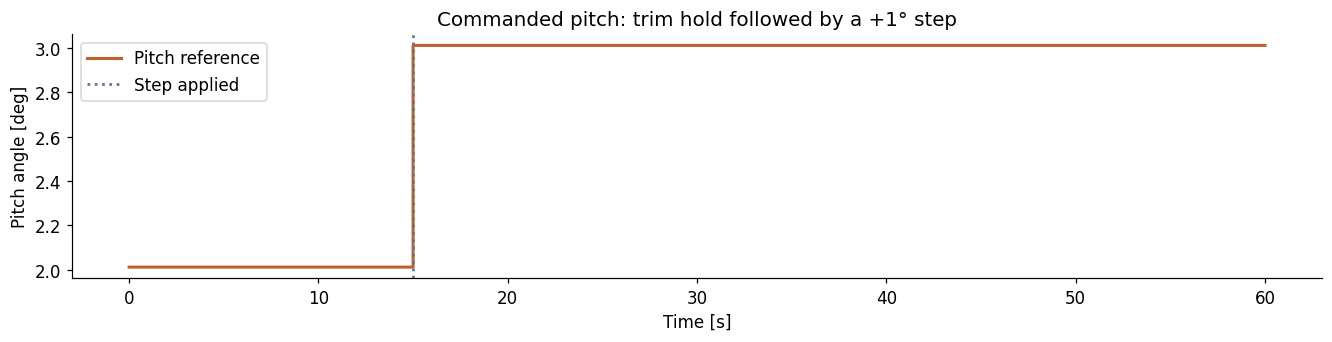

In [2]:
experiment = B737PitchStepBenchmark(duration=60.0, dt=0.02, step_time=15.0, step_deg=1.0)
env, trim_result, trim_action = experiment.make_env()
state, _ = env.reset(seed=experiment.seed)
params = env.unwrapped.model.param
theta_trim = trim_result.alpha_rad
reference = experiment.reference
OUTER_PITCH_GAIN = 0.8  # q_ref = gain * (theta_ref - theta), clipped to ±3 deg/s

print(f"Trim residual: {trim_result.residual:.3e}")
print(f"Pitch: {np.rad2deg(theta_trim):.4f} deg; "
      f"elevator: {np.rad2deg(trim_action[0]):.4f} deg; "
      f"throttle: {trim_action[3]:.4f}")
print(f"{experiment.steps} transitions; {experiment.steps + 1} state samples; "
      f"final time {experiment.time[-1]:.1f} s")
experiment.plot_reference(theta_trim)
plt.show()


## 2. SI sensors, aircraft geometry and controller setup

The model uses feet, slugs and radians; AA-INDI uses SI throughout. `geometry_si` includes
B737's product of inertia with the same sign convention as the nonlinear equations.
`FlightMeasurement.from_model` synthesizes ideal accelerometer, gyro, navigation and air-data measurements:

`f_body = (v_dot_body + omega × v_body - R_body_to_NED.T @ g_NED) * 0.3048`.

Navigation velocity and attitude come independently from simulated aircraft truth, not
from integrating the gyro. No noise or sensor/actuator fault is injected in this example.
The ODE is used to synthesize accelerometers; its true angular acceleration and moment
are **not** supplied to the observer or online identifier. Surface feedback is the actual
held elevator from the preceding interval. Sampling is 50 Hz for every channel.

The controller starts from a **one-time nominal elevator derivative at trim**. It controls
only pitch; the symmetric initial state and zero lateral inputs keep roll/yaw unforced.
The angle loop produces `q_ref`; `predict` applies rate feedback
`nu_q = 3 * (q_ref - corrected_q)` before the AA-INDI acceleration loop.
Its 20°/s command limit and 5 Hz acceleration filter are example settings.


In [3]:
from tensoraerospace.agent.aa_indi import AAINDIAgent, AAINDIConfig, ObserverConfig

geometry = AircraftGeometry.from_parameters(params)
measurement = FlightMeasurement.from_model(env.model, applied_action=trim_action, surface_indices=(0,))
A_cont, B_cont = env.model.linearize(state, trim_action)
b = B_cont[4, 0]
nominal_derivatives = geometry.coefficients(
    np.zeros(3), np.array([0.0, b, 0.0]), measurement.density, measurement.airspeed,
)[:, None]
agent = AAINDIAgent(AAINDIConfig(
    geometry=geometry, nominal_derivatives=nominal_derivatives,
    observer=ObserverConfig(dt=experiment.dt, gravity=params.g_ft_s2 * 0.3048),
    sigma0=15.0, forgetting_min=0.25, covariance_init=1.0,
    rate_feedback=np.full(3, 3.0), acceleration_cutoff_hz=5.0,
    magnitude_limit=params.elevator_max_rad, rate_limit=np.deg2rad(20.0),
    enable_sensor_correction=True,
))
print(f"Nominal Cm_delta_e: {nominal_derivatives[1, 0]:.6f} 1/rad")
print(f"Trim airspeed: {measurement.airspeed:.3f} m/s; density: {measurement.density:.6f} kg/m³")
print("Trim specific force [m/s²]:", measurement.specific_force)


Nominal Cm_delta_e: -1.027479 1/rad
Trim airspeed: 198.120 m/s; density: 0.652977 kg/m³
Trim specific force [m/s²]: [ 0.34423586  0.         -9.8005916 ]


### What the online coefficient estimate means here

The paper's control-only regression fits total reconstructed moment coefficients against
absolute surface positions. B737's pitching moment also depends on angle of attack and
pitch rate; at trim, its nonzero elevator balances other aerodynamic moments. Consequently,
a fitted `Cm_delta_e` can drift even without a fault. It is an **effective coefficient of
this reduced regression**, not a verified physical elevator derivative or a fault percentage.

The nominal prior and `covariance_init=1` are explicit experimental choices. All three
VFF-RLS estimators and the sensor observer continue updating every interval. This step
scenario does not provide enough independent excitation to validate parameter identification.


## 3. Run all 3,000 plant transitions

The next sensor packet is constructed after `env.step` from the new state and actual
applied elevator. `learn` consumes it once; the next `predict` reuses the identical packet
at that timestamp. Environment clipping is included in the feedback. No trim offset is
subtracted from the AA-INDI surface measurement or moment-identification regressor.


In [4]:
states, actions, rate_commands, learning = [state.copy()], [], [], []
try:
    for k in range(experiment.steps):
        q_ref = float(np.clip(OUTER_PITCH_GAIN * (theta_trim + reference[k] - state[7]),
                              -np.deg2rad(3.0), np.deg2rad(3.0)))
        command = agent.predict(measurement, np.array([0.0, q_ref, 0.0]))
        action = trim_action.copy()
        action[0] = command[0]  # AA-INDI returns the absolute surface angle.
        action = np.clip(action, env.action_space.low, env.action_space.high)
        next_state, _, terminated, truncated, _ = env.step(action)
        applied = env.model.applied_action
        experiment.validate_transition(next_state, terminated, truncated, k)
        measurement = FlightMeasurement.from_model(env.model, surface_indices=(0,))
        diagnostics = agent.learn(measurement, applied_action=applied[:1])
        learning.append([
            agent.identifier.derivatives[1, 0], agent.G[1, 0],
            agent.observer.faults[4], diagnostics["moment_residual_norm"],
        ])
        states.append(next_state.copy())
        actions.append(applied)
        rate_commands.append(q_ref)
        state = next_state
finally:
    env.close()
states, actions, rate_commands, learning = map(np.asarray, (states, actions, rate_commands, learning))
assert np.isfinite(learning).all()
update_counts = [estimator.num_updates for estimator in agent.identifier.estimators]
assert update_counts == [experiment.steps] * 3
print(f"Completed {experiment.duration:.1f} s; VFF-RLS updates per moment axis: {update_counts}")
print(f"Final fitted Cm_delta_e: {learning[-1, 0]:.6f} 1/rad")
print(f"Final reconstructed q-gyro bias: {np.rad2deg(learning[-1, 2]):.6f} deg/s (true bias: zero)")


Completed 60.0 s; VFF-RLS updates per moment axis: [3000, 3000, 3000]
Final fitted Cm_delta_e: -0.415273 1/rad
Final reconstructed q-gyro bias: 0.005421 deg/s (true bias: zero)


## 4. Tracking, accumulated error and observer/identifier diagnostics

The gyro-bias plot is compared with the known **zero injected bias** for evaluation only;
that truth is not fed to the controller. A changing `Cm_delta_e` estimate is not, by itself,
evidence of an actuator fault. `G_q` also changes with airspeed and density.


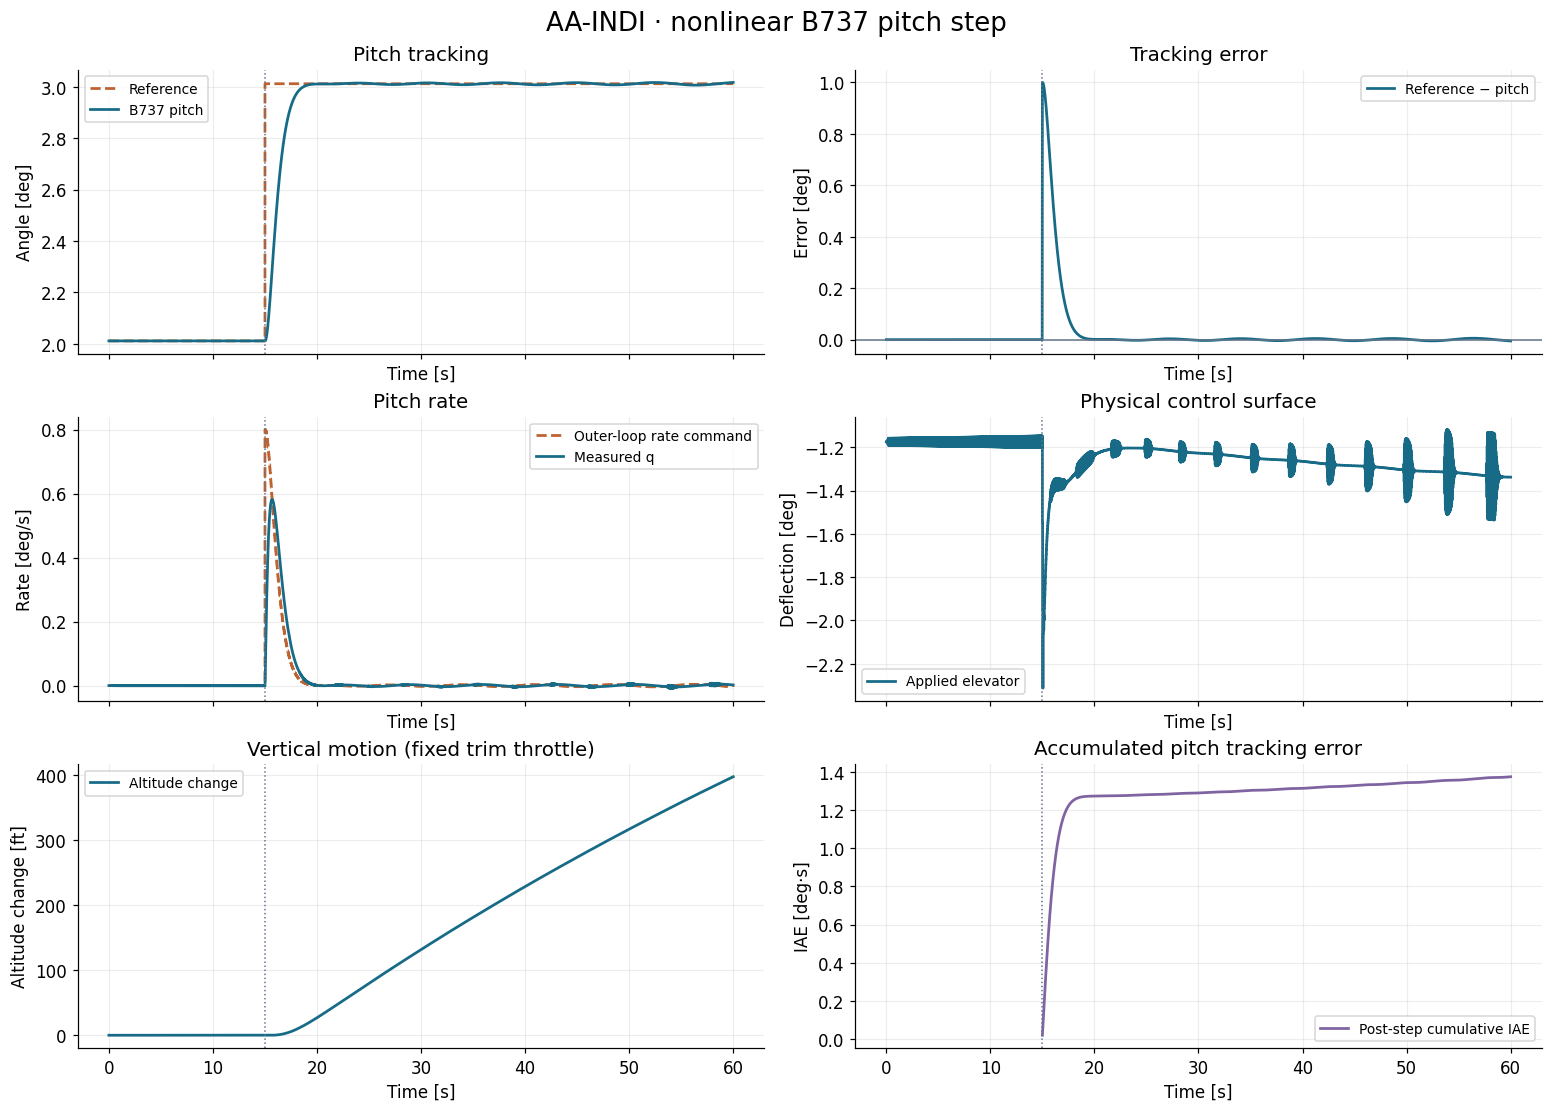

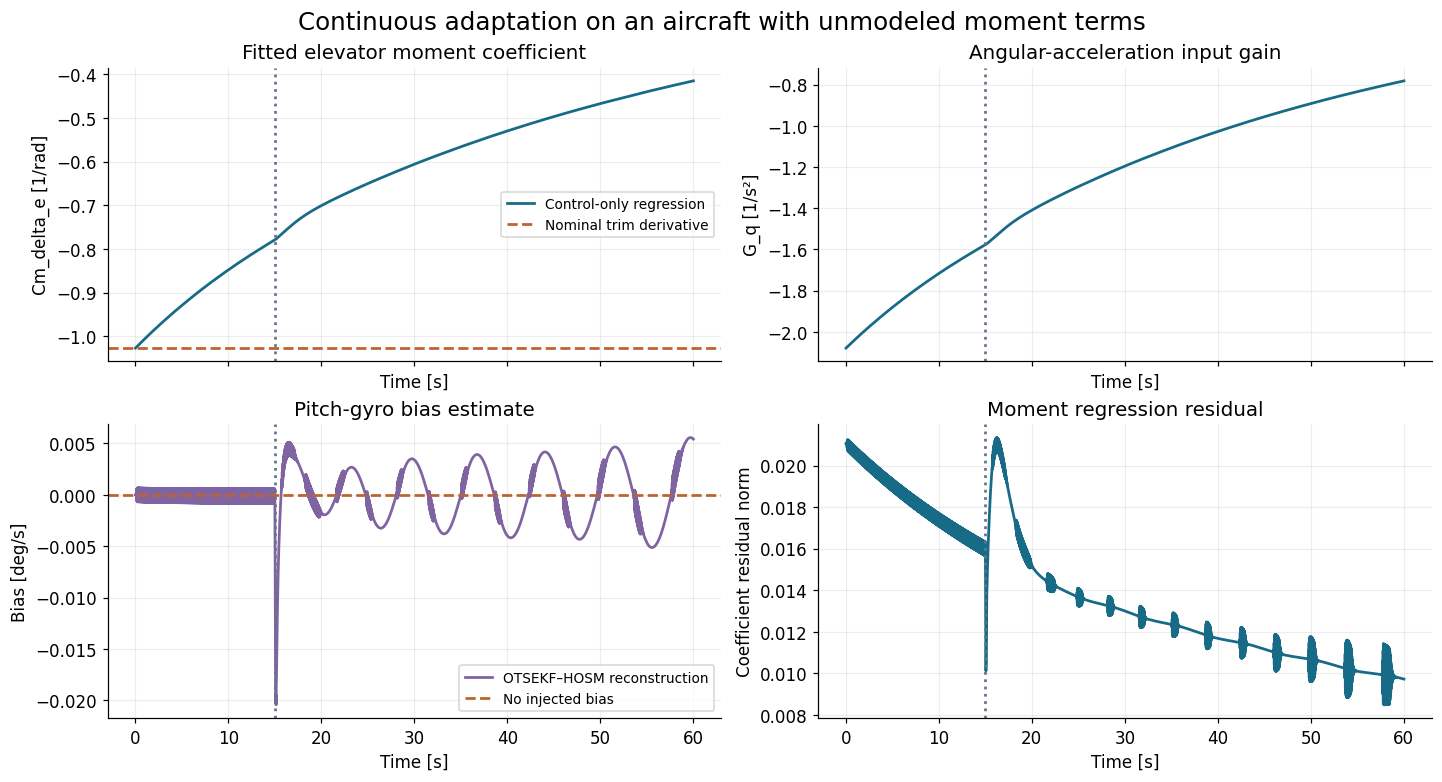

In [5]:
experiment.plot_response(states, actions, rate_commands, "AA-INDI · nonlinear B737 pitch step")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True, constrained_layout=True)
axes[0, 0].plot(experiment.time[1:], learning[:, 0], color="#176b87", label="Control-only regression")
axes[0, 0].axhline(nominal_derivatives[1, 0], color="#bd6230", linestyle="--", label="Nominal trim derivative")
axes[0, 0].set(title="Fitted elevator moment coefficient", ylabel="Cm_delta_e [1/rad]")
axes[0, 0].legend(fontsize=9)
axes[0, 1].plot(experiment.time[1:], learning[:, 1], color="#176b87")
axes[0, 1].set(title="Angular-acceleration input gain", ylabel="G_q [1/s²]")
axes[1, 0].plot(experiment.time[1:], np.rad2deg(learning[:, 2]), color="#8064a2", label="OTSEKF–HOSM reconstruction")
axes[1, 0].axhline(0, color="#bd6230", linestyle="--", label="No injected bias")
axes[1, 0].set(title="Pitch-gyro bias estimate", ylabel="Bias [deg/s]")
axes[1, 0].legend(fontsize=9)
axes[1, 1].plot(experiment.time[1:], learning[:, 3], color="#176b87")
axes[1, 1].set(title="Moment regression residual", ylabel="Coefficient residual norm")
for axis in axes.ravel():
    axis.axvline(experiment.step_time, color="#64748b", linestyle=":")
    axis.set_xlabel("Time [s]")
    axis.grid(alpha=0.22)
fig.suptitle("Continuous adaptation on an aircraft with unmodeled moment terms", fontsize=16)
plt.show()


## 5. Step-response assessment with `ControlBenchmark`

`evaluate_step` calls the repository's `ControlBenchmark.benchmarking_one_step` with
**pitch deviations in radians**, a zero pre-step baseline, and one second of pre-step data.
It refuses partial or non-finite trajectories. The table converts angle-based metrics to degrees.
Two windows distinguish the initial transient from later adaptation: the first 15 s after
the step, and the complete 45 s post-step interval.

The benchmark computes overshoot and its ±5% settling band relative to the **estimated
final output**, not the requested pitch. We report those native metrics unchanged and
add separately labelled overshoot/settling metrics relative to the **command**. Settling
requires staying in the corresponding band for the rest of the selected window.
The shaded plot uses the command band. Rise time is the **10–90% duration relative to
the estimated final output**, not a timestamp or a test of reaching the command.
Static error uses the benchmark's steady tail; the separate final error is a single sample.
IAE sums absolute pitch error times `dt` using the benchmark's rectangle rule; the
cumulative plot uses the same convention. ISE integrates squared error; ITAE additionally
weights elapsed time after the step. Rate-loop error is not added to angle error because their units differ.


,First 15 s after step,Full post-step interval
Overshoot vs. final output [%],0.19009,0.69019
"Settling around final output, 5% [s]",2.90000,2.86000
Overshoot vs. command [%],0.29322,0.50903
"Settling around command, 5% [s]",2.88000,2.88000
"Rise time, 10–90% [s]",2.04000,2.02000
Peak time [s],5.22000,5.22000
Static error [deg],-0.00148,0.00161
IAE [deg·s],1.28893,1.37376
ISE [deg²·s],0.82597,0.82626
ITAE [deg·s²],1.30800,3.92301


,Measured result
Completed time [s],60.000000
Post-step pitch RMSE [deg],0.135474
Post-step pitch MAE [deg],0.030514
Final pitch error [deg],-0.005090
Peak |q| [deg/s],0.581952
Peak |elevator| [deg],2.312315
Altitude change [ft],397.753433
Airspeed change [ft/s],-18.839934


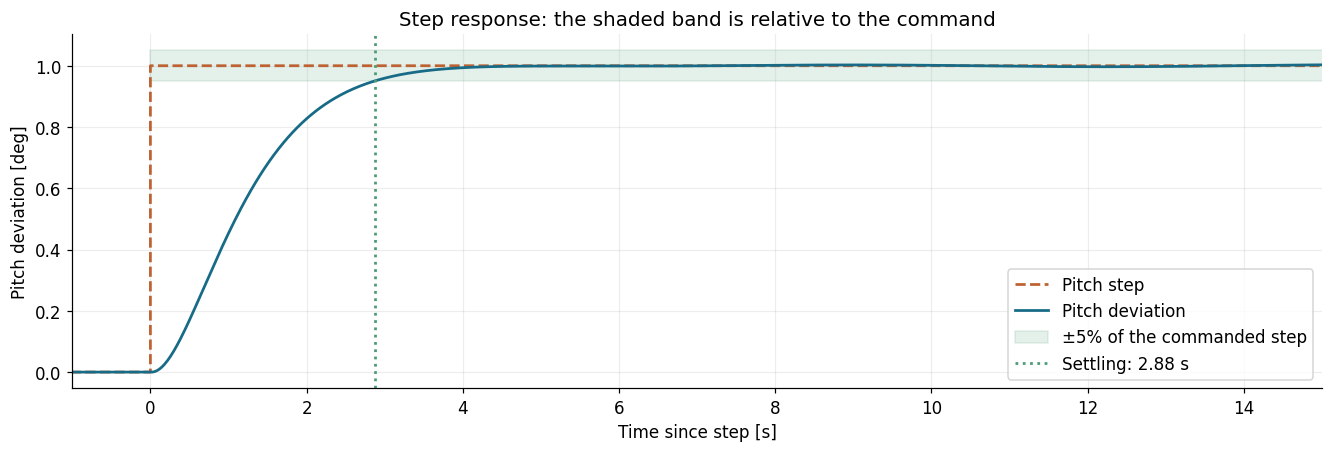

In [6]:
windows, physical_metrics = experiment.evaluate(states, actions)
display(experiment.metric_table(windows).style.format(precision=5, na_rep="Not reached"))
display(pd.Series(physical_metrics, name="Measured result").to_frame().style.format(precision=6))
experiment.plot_step(states, windows)
plt.show()


## 6. Interpretation

All curves and tables above are generated by the saved run. A full finite episode and
small tracking error support this **nominal, ideal-sensor, 60 s test only**; they do not
establish global stability or fault tolerance. No fault is injected and no policy is frozen.
The altitude increase and airspeed reduction are expected with a sustained nose-up command
and fixed throttle: this experiment controls pitch, not altitude or speed.

The public `tensoraerospace` API supplies model analysis, measurements and
benchmark metrics. This notebook only defines the application reference, agent
configuration and control loop; it does not depend on sibling examples.
